In [ ]:
# Google Colab / Local detection
DATA_PATH = '/content/drive/Data'

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive mounted")
except ImportError:
    DATA_PATH = 'Data'
    print("✅ Running locally")

print(f"📁 Loading: {DATA_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted
📁 Loading: /content/drive/MyDrive/MMA_865/Data



# **This notebook performs:**
1. FULL EDA (train only — no leakage)
2. Builds a simple, defensible baseline model:
      - Uses only prediction-time features
      - 80/20 stratified train/hold-out split
      - Preprocessing inside a Pipeline (no leakage)
      - Logistic Regression (class_weight='balanced')
      - 5-fold CV ROC-AUC on train portion only
      - Final evaluation on untouched hold-out set

This baseline is the mandatory control for all iterative improvements.

# **Import Libraries**

In [55]:
# Data manipulation and numerical computing
import os
import time
import numpy as np
import pandas as pd

# EDA
import seaborn as sns # For EDA
import matplotlib.pyplot as plt

# # Machine learning libraries
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

# Set seaborn style and random seed for reproducibility
sns.set(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

'''These grouping comments were added to organize imports by purpose for better code readability'''

'These grouping comments were added to organize imports by purpose for better code readability'

# Data Loading

#TRAIN ONLY — TEST NOT USED IN BASELINE

*   Train: used for EDA, baseline, and all modeling
*   Test: loaded only for later use (no training here)


In [56]:
# ==============================================================================
# 1. LOAD DATA
# ==============================================================================

TRAIN_PATH = '/content/drive/MyDrive/MMA_865/Data/train.csv'
TEST_PATH  = '/content/drive/MyDrive/MMA_865/Data/test.csv'


train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape:     {test_df.shape}")

# ==============================================================================
# DEFINE FEATURES (X) AND LABEL (y)
# - Use only prediction-time features (drop target and Id)
# ==============================================================================

TARGET_COL = 'SeriousDlqin2yrs'
ID_COL     = 'Id'

y_full = train_df[TARGET_COL].copy()
X_full = train_df.drop([TARGET_COL, ID_COL], axis=1).copy()

print("\nFeature matrix and target defined:")
print(f"  X_full shape: {X_full.shape}")
print(f"  y_full shape: {y_full.shape}")
print(f"  Positive rate (default=1): {y_full.mean():.4f}")

Training data shape: (104805, 12)
Test data shape:     (45195, 11)

Feature matrix and target defined:
  X_full shape: (104805, 10)
  y_full shape: (104805,)
  Positive rate (default=1): 0.0663


# EDA


*   Goal is to understand structure , outliers, imbalance, missing distributions and correlations using only Train data.


================ BASIC INFO ================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104805 entries, 0 to 104804
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    104805 non-null  int64  
 1   SeriousDlqin2yrs                      104805 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float64
 3   age                                   104805 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  104805 non-null  int64  
 5   DebtRatio                             104805 non-null  float64
 6   MonthlyIncome                         84024 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       104805 non-null  int64  
 8   NumberOfTimes90DaysLate               104805 non-null  int64  
 9   NumberRealEstateLoansOrLines          104805 non-null  int64  
 10  NumberOfTime60-89DaysP

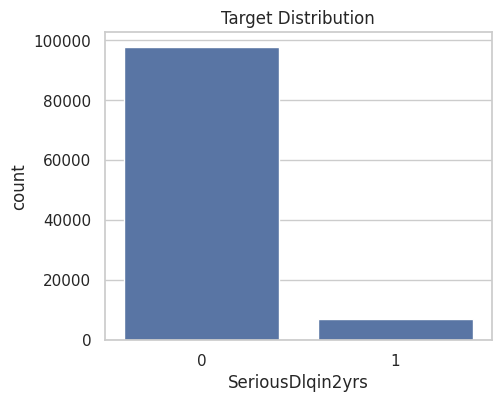


================ MISSING VALUES ================
MonthlyIncome         20781
NumberOfDependents     2749
dtype: int64


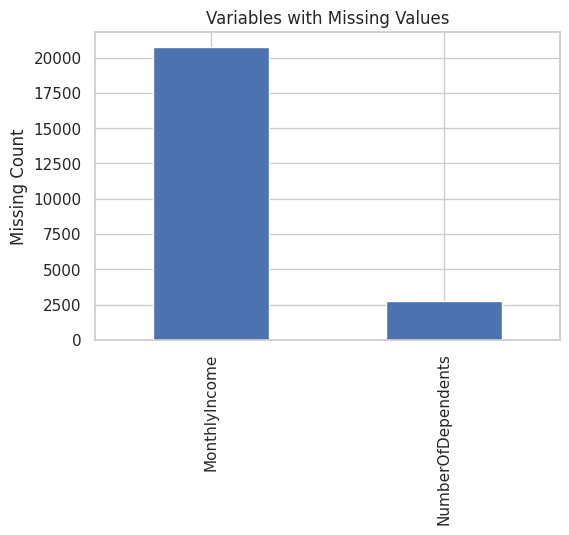

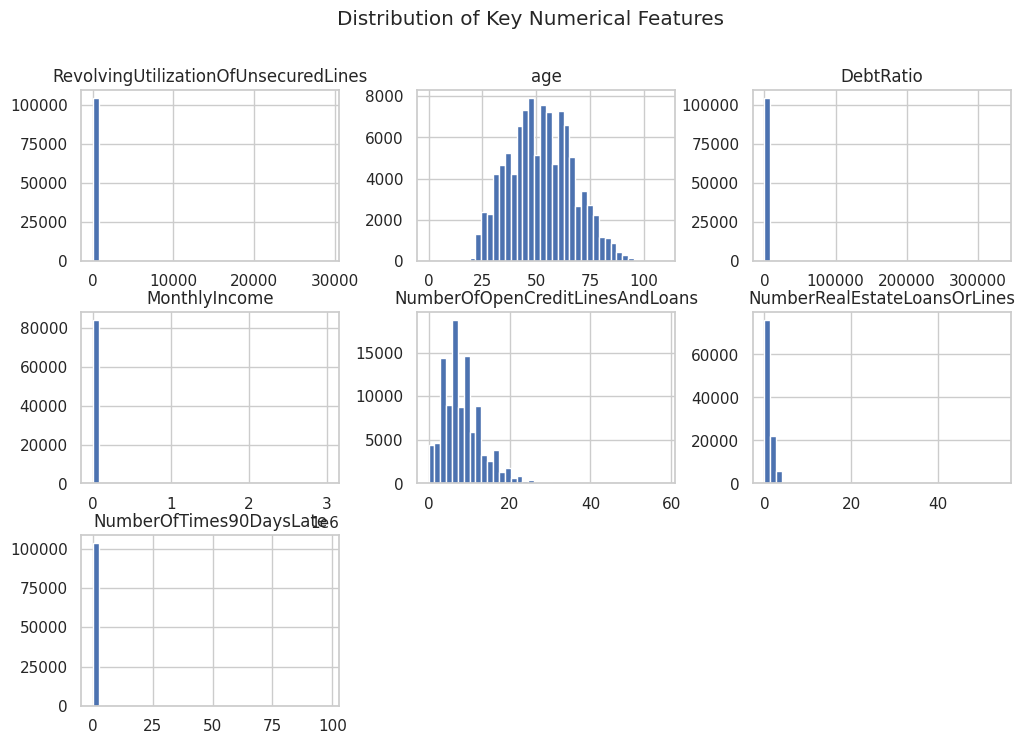

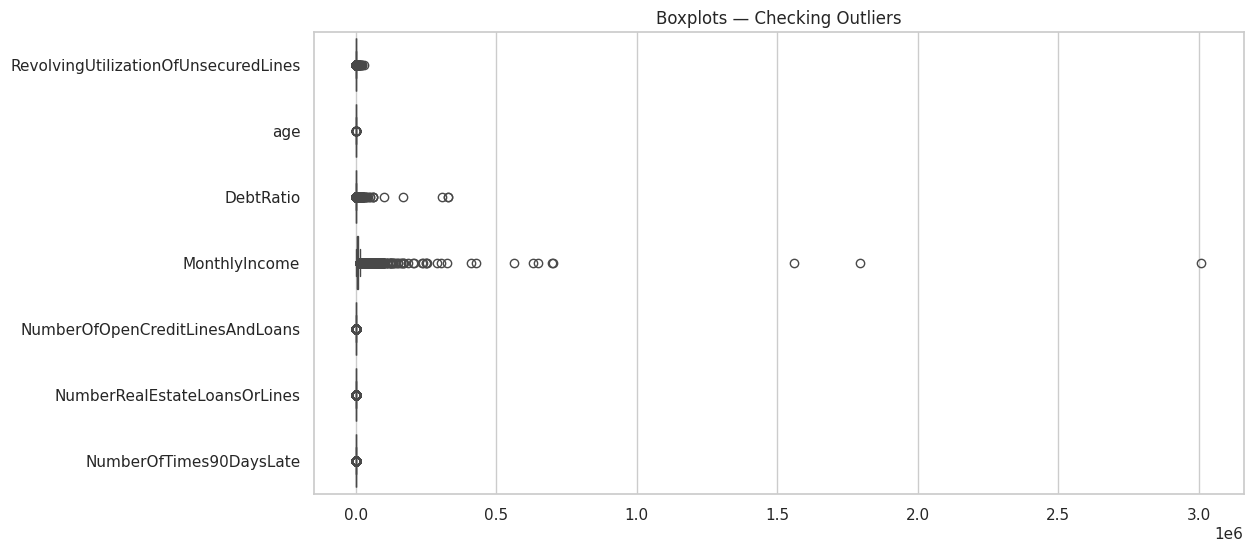

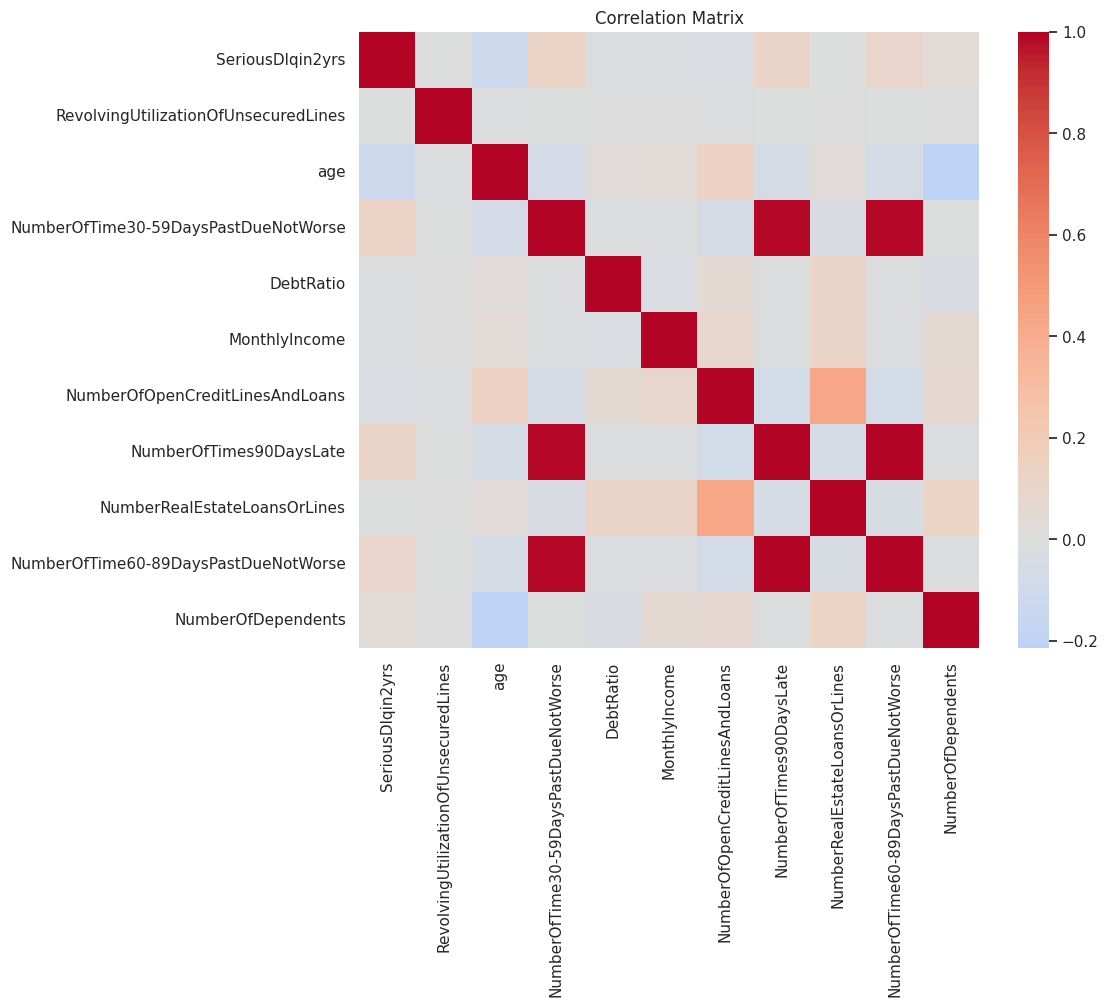

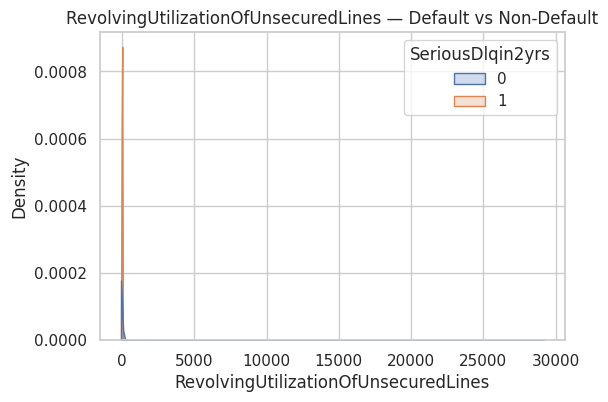

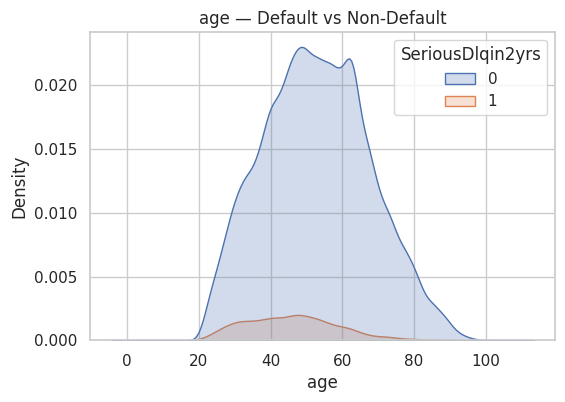

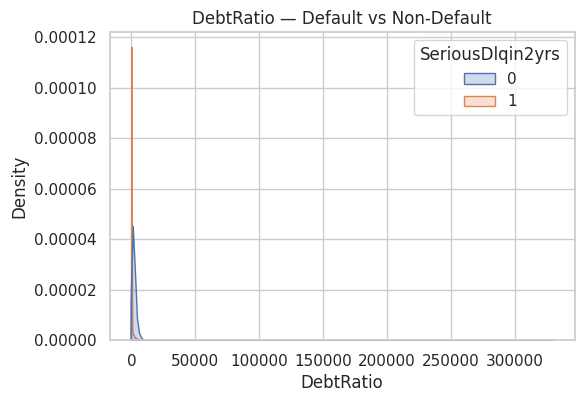

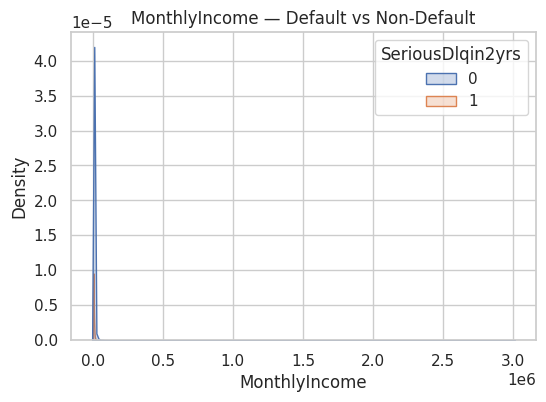

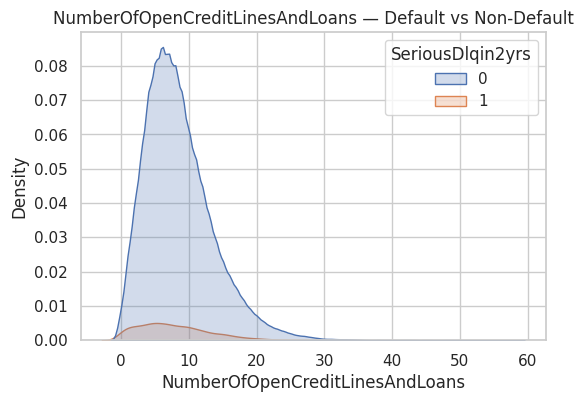

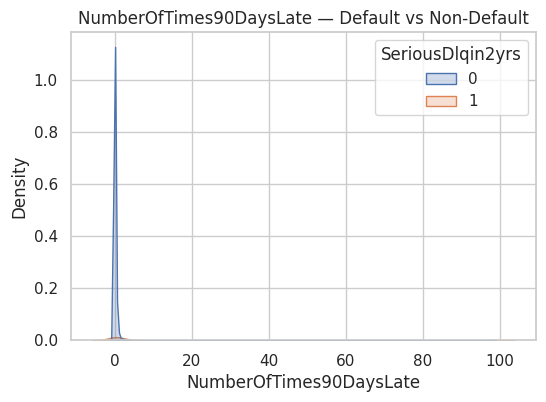


================ EDA INSIGHTS ================

1. Severe class imbalance (~6–7% defaults).
2. Missing values mainly in MonthlyIncome & NumberOfDependents.
3. Many heavy-tailed variables (DebtRatio, Utilization).
4. Past-due counts strongly predictive.
5. Younger borrowers show slightly higher risk.
6. Outliers justify future winsorization or clipping (in advanced pipeline).



In [57]:
# ==============================================================================
# 2. EDA
# ==============================================================================

print("\n================ BASIC INFO ================")
print(train_df.info())

print("\n================ SUMMARY STATS ================")
print(train_df.describe().T)

# --- Class distribution
print("\n================ CLASS DISTRIBUTION ================")
target_counts = train_df['SeriousDlqin2yrs'].value_counts()
print(target_counts)
print(f"\nDefault rate: {target_counts[1] / target_counts.sum():.4f}")

plt.figure(figsize=(5,4))
sns.countplot(data=train_df, x='SeriousDlqin2yrs')
plt.title("Target Distribution")
plt.show()

# --- Missingness
# Initial AI code calculated percentages incorrectly.
# Rather than re-prompting I fixed the calculation directly to ensure accuracy.
print("\n================ MISSING VALUES ================")
missing = train_df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

plt.figure(figsize=(6,4))
missing[missing > 0].plot(kind='bar')
plt.title("Variables with Missing Values")
plt.ylabel("Missing Count")
plt.show()

# --- Numeric distributions
num_cols = [
    'RevolvingUtilizationOfUnsecuredLines','age','DebtRatio',
    'MonthlyIncome','NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines','NumberOfTimes90DaysLate'
]
# Histograms help reveal skewness, heavy tails, and outliers
train_df[num_cols].hist(figsize=(12,8), bins=40)
plt.suptitle("Distribution of Key Numerical Features")
plt.show()


# ---Outlier check via boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=train_df[num_cols], orient='h')
plt.title("Boxplots — Checking Outliers")
plt.show()

# --- Correlation matrix to detect linear relationships among features and target
plt.figure(figsize=(10,8))
corr = train_df.drop(['Id'], axis=1).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

# --- Risk curves: feature distributions by default vs non-default
risk_cols = [
    'RevolvingUtilizationOfUnsecuredLines','age','DebtRatio',
    'MonthlyIncome','NumberOfOpenCreditLinesAndLoans','NumberOfTimes90DaysLate'
]

for col in risk_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=train_df, x=col, hue='SeriousDlqin2yrs', fill=True)
    plt.title(f"{col} — Default vs Non-Default")
    plt.show()

print("\n================ EDA INSIGHTS ================")
print("""
1. Severe class imbalance (~6–7% defaults).
2. Missing values mainly in MonthlyIncome & NumberOfDependents.
3. Many heavy-tailed variables (DebtRatio, Utilization).
4. Past-due counts strongly predictive.
5. Younger borrowers show slightly higher risk.
6. Outliers justify future winsorization or clipping (in advanced pipeline).
""")

In [58]:
# ==============================================================================
# 3. TRAIN / HOLD-OUT SPLIT (80/20 STRATIFIED)
# - Train split: used for CV + model fitting
# - Hold-out split: untouched until final evaluation
# ==============================================================================

# Ensure features and target are defined

target_col = "SeriousDlqin2yrs"
X = train_df.drop(columns=[target_col])
y = train_df[target_col]

print(X.shape, y.shape)


X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTrain / Hold-out split:")
print(f"  X_train: {X_train.shape}")
print(f"  X_holdout: {X_holdout.shape}")
print(f"  Train default rate:   {y_train.mean():.4f}")
print(f"  Hold-out default rate:{y_holdout.mean():.4f}")

# ==============================================================================
# 4. BASELINE PIPELINE – LOGISTIC REGRESSION
#    - Median imputation for numeric NaNs
#    - Standardization for all features
#    - Logistic Regression with class_weight='balanced' for imbalance
#    - All inside Pipeline → prevents data leakage
# ==============================================================================

baseline_clf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)


(104805, 11) (104805,)

Train / Hold-out split:
  X_train: (83844, 11)
  X_holdout: (20961, 11)
  Train default rate:   0.0663
  Hold-out default rate:0.0663


In [59]:
# ==============================================================================
# 5. CROSS-VALIDATION ON TRAINING PORTION ONLY
# - 5-fold StratifiedKFold to preserve class balance across folds
# - Evaluate ROC-AUC (competition metric)
# ==============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("\nPerforming 5-fold CV on training split...")
cv_scores = cross_val_score(
    baseline_clf,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("\nCross-validated ROC-AUC:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean CV ROC-AUC: {cv_scores.mean():.4f}")
print(f"  Std CV ROC-AUC:  {cv_scores.std():.4f}")


Performing 5-fold CV on training split...

Cross-validated ROC-AUC:
  Fold 1: 0.7893
  Fold 2: 0.7890
  Fold 3: 0.7842
  Fold 4: 0.7903
  Fold 5: 0.7941
  Mean CV ROC-AUC: 0.7894
  Std CV ROC-AUC:  0.0032


In [60]:
# ==============================================================================
# 6. FIT BASELINE AND EVALUATE ON HOLD-OUT
#    - Train on full training split
#    - Evaluate once on untouched hold-out (simulating production)
# ==============================================================================
print("\nFitting baseline model on train split...")
baseline_clf.fit(X_train, y_train)

# Predicted probabilities and class labels on hold-out
holdout_proba = baseline_clf.predict_proba(X_holdout)[:, 1]
holdout_pred  = baseline_clf.predict(X_holdout)

# ROC-AUC and confusion matrix on hold-out
holdout_auc = roc_auc_score(y_holdout, holdout_proba)
cm = confusion_matrix(y_holdout, holdout_pred)

print(f"\nHOLD-OUT ROC-AUC: {holdout_auc:.4f}")
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_holdout, holdout_pred, digits=3))


Fitting baseline model on train split...

HOLD-OUT ROC-AUC: 0.7828

Confusion Matrix:
[[15022  4549]
 [  505   885]]

Classification Report:
              precision    recall  f1-score   support

           0      0.967     0.768     0.856     19571
           1      0.163     0.637     0.259      1390

    accuracy                          0.759     20961
   macro avg      0.565     0.702     0.558     20961
weighted avg      0.914     0.759     0.816     20961



In [61]:

# ==============================================================================
# 7. SUMMARY
# - This defines the baseline performance that all complex models must beat
# ==============================================================================
print("\n" + "="*80)
print("BASELINE SUMMARY")
print("="*80)
print(f"- Model: Logistic Regression (median imputation + standardization)")
print(f"- Train: 80% | Hold-out: 20% (stratified)")
print(f"- CV ROC-AUC (train only): {cv_scores.mean():.4f}")
print(f"- Hold-out ROC-AUC:        {holdout_auc:.4f}")
print("This baseline serves as the control for all advanced iterations.")


BASELINE SUMMARY
- Model: Logistic Regression (median imputation + standardization)
- Train: 80% | Hold-out: 20% (stratified)
- CV ROC-AUC (train only): 0.7894
- Hold-out ROC-AUC:        0.7828
This baseline serves as the control for all advanced iterations.


**ITERATIVE MODELING BEYOND BASELINE – CREDIT RISK**
  - Tries multiple preprocessing + modeling variants
  - Compares CV ROC-AUC vs hold-out ROC-AUC
  - Runs transparent hyperparameter tuning for XGBoost
  - Identifies a best model
  - Produces confusion matrix, metrics, feature importance, and example predictions



In [62]:
# ------------------------------------------------------------------------------
# 8. FEATURE ENGINEERING FUNCTION (NO LEAKAGE – USES ONLY X)
#  - Encapsulates domain-driven feature creation from original predictors.
#  - Used inside Pipelines so it only sees training data in each fold.
# ------------------------------------------------------------------------------

def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """Domain-based feature engineering."""
    df = df.copy()

    # Income per dependent
    df["IncomePerDependent"] = np.where(
        df["NumberOfDependents"] > 0,
        df["MonthlyIncome"] / (df["NumberOfDependents"] + 1),
        df["MonthlyIncome"]
    )

    # Payment behavior
    df["TotalPastDue"] = (
        df["NumberOfTime30-59DaysPastDueNotWorse"]
        + df["NumberOfTime60-89DaysPastDueNotWorse"]
        + df["NumberOfTimes90DaysLate"]
    )

    df["WorstDelinquency"] = df[
        [
            "NumberOfTime30-59DaysPastDueNotWorse",
            "NumberOfTime60-89DaysPastDueNotWorse",
            "NumberOfTimes90DaysLate",
        ]
    ].max(axis=1)

    df["RecentDelinquencies"] = (
        (df["NumberOfTime30-59DaysPastDueNotWorse"] > 0)
        | (df["NumberOfTime60-89DaysPastDueNotWorse"] > 0)
        | (df["NumberOfTimes90DaysLate"] > 0)
    ).astype(int)

    df["MultipleDelinquencies"] = (
        (df["NumberOfTime30-59DaysPastDueNotWorse"] > 1)
        | (df["NumberOfTime60-89DaysPastDueNotWorse"] > 1)
        | (df["NumberOfTimes90DaysLate"] > 1)
    ).astype(int)

    # Credit utilization buckets
    df["HighUtilization"] = (
        df["RevolvingUtilizationOfUnsecuredLines"] > 0.7
    ).astype(int)
    df["ModerateUtilization"] = (
        (df["RevolvingUtilizationOfUnsecuredLines"] >= 0.3)
        & (df["RevolvingUtilizationOfUnsecuredLines"] <= 0.7)
    ).astype(int)

    # Age groups
    df["IsYoung"] = (df["age"] < 35).astype(int)
    df["IsMiddleAge"] = ((df["age"] >= 35) & (df["age"] < 60)).astype(int)
    df["IsSenior"] = (df["age"] >= 60).astype(int)

    # Income levels
    df["LowIncome"] = (df["MonthlyIncome"] <= 4633).astype(int)
    df["MiddleIncome"] = (
        (df["MonthlyIncome"] > 4633) & (df["MonthlyIncome"] <= 6200)
    ).astype(int)

    # Debt burden
    df["HighDebtBurden"] = (df["DebtRatio"] > 0.5).astype(int)

    df["DebtPerLoC"] = np.where(
        df["NumberOfOpenCreditLinesAndLoans"] > 0,
        df["DebtRatio"] / df["NumberOfOpenCreditLinesAndLoans"],
        0,
    )

    df["RevolvingBalancePerLoC"] = np.where(
        df["NumberOfOpenCreditLinesAndLoans"] > 0,
        df["RevolvingUtilizationOfUnsecuredLines"]
        / df["NumberOfOpenCreditLinesAndLoans"],
        0,
    )

    return df

# Wrap feature engineering inside a sklearn transformer for use in Pipelines
feature_engineering = FunctionTransformer(create_features, validate=False)

# # Keep explicit names for clarity in iterative experiments
X_iter_train = X_train.copy()
y_iter_train = y_train.copy()
X_iter_holdout = X_holdout.copy()
y_iter_holdout = y_holdout.copy()

'''These headers organize features by business logic,
making it easier to validate that each feature makes credit risk sense.'''

# ------------------------------------------------------------------------------
# 9. CLASS IMBALANCE WEIGHT FOR XGBOOST
# - Compute negative/positive ratio to set scale_pos_weight.
# ------------------------------------------------------------------------------
neg, pos = np.bincount(y_iter_train)
scale_pos_weight = neg / pos
print(f"\nscale_pos_weight (train): {scale_pos_weight:.2f}")



scale_pos_weight (train): 14.08


In [63]:
#===============================================================================
# 10. DEFINE MULTIPLE PIPELINES (PREPROCESSING + MODEL)
# - Each Pipeline: FE (optional) → impute → (scale if needed) → model
# - All transformations occur within CV folds → no leakage
#===============================================================================

pipelines = {}

# Variant 1: Raw features, simple impute + scale + logistic
pipelines["LogReg_basic"] = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000,
            class_weight="balanced",
        )),
    ]
)

# Variant 2: Feature-engineered, impute + scale + logistic
pipelines["LogReg_FE"] = Pipeline(
    steps=[
        ("fe", feature_engineering),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000,
            class_weight="balanced",
        )),
    ]
)

# Variant 3: Feature-engineered, impute + Random Forest
pipelines["RF_FE"] = Pipeline(
    steps=[
        ("fe", feature_engineering),
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
        )),
    ]
)

# Variant 4: Feature-engineered, impute + baseline XGBoost
pipelines["XGB_FE"] = Pipeline(
    steps=[
        ("fe", feature_engineering),
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            use_label_encoder=False,
            scale_pos_weight=scale_pos_weight,
        )),
    ]
)

# Variant 5: Feature-engineered, impute + LightGBM
pipelines["LGBM_FE"] = Pipeline(
    steps=[
        ("fe", feature_engineering),
        ("imputer", SimpleImputer(strategy="median")),
        ("lgbm", LGBMClassifier(
            n_estimators=300,
            num_leaves=31,
            max_depth=6,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
            verbosity=-1,
        )),
    ]
)

In [64]:
#===============================================================================
# 11. EVALUATION FUNCTION – CV VS HOLD-OUT
# - For each Pipeline:
#   * 5-fold CV ROC-AUC on training split only
#   * Fit on full training split
#   * Evaluate ROC-AUC, precision, recall, F1 on hold-out
#===============================================================================

cv_iter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

def evaluate_pipeline(name, pipeline, X_tr, y_tr, X_ho, y_ho):
    print(f"\n===== Evaluating: {name} =====")

    # Cross-validation on training portion only
    cv_scores = cross_val_score(
        pipeline,
        X_tr,
        y_tr,
        cv=cv_iter,
        scoring="roc_auc",
        n_jobs=-1,
    )
    print(f"CV ROC-AUC (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Fit on full training portion
    pipeline.fit(X_tr, y_tr)

    # Evaluate on untouched hold-out set
    proba = pipeline.predict_proba(X_ho)[:, 1]
    pred  = pipeline.predict(X_ho)

    hold_auc = roc_auc_score(y_ho, proba)
    hold_prec = precision_score(y_ho, pred)
    hold_rec = recall_score(y_ho, pred)
    hold_f1 = f1_score(y_ho, pred)

    print(f"Hold-out ROC-AUC: {hold_auc:.4f}")
    print(f"Hold-out Precision: {hold_prec:.4f}")
    print(f"Hold-out Recall:    {hold_rec:.4f}")
    print(f"Hold-out F1:        {hold_f1:.4f}")

    return {
        "model": name,
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std(),
        "holdout_auc": hold_auc,
        "holdout_precision": hold_prec,
        "holdout_recall": hold_rec,
        "holdout_f1": hold_f1,
        "pipeline": pipeline,
    }

In [65]:
# ------------------------------------------------------------------------------
# 12. RUN ALL PIPELINES AND BUILD COMPARISON TABLE
# - Collect CV and hold-out metrics for each model
# ------------------------------------------------------------------------------

results_list = []
for name, pipe in pipelines.items():
    res = evaluate_pipeline(
        name,
        pipe,
        X_iter_train,
        y_iter_train,
        X_iter_holdout,
        y_iter_holdout,
    )
    results_list.append(res)

results_df = pd.DataFrame(
    [
        {
            "model": r["model"],
            "cv_auc_mean": r["cv_auc_mean"],
            "cv_auc_std": r["cv_auc_std"],
            "holdout_auc": r["holdout_auc"],
            "holdout_precision": r["holdout_precision"],
            "holdout_recall": r["holdout_recall"],
            "holdout_f1": r["holdout_f1"],
        }
        for r in results_list
    ]
).sort_values("holdout_auc", ascending=False)



===== Evaluating: LogReg_basic =====
CV ROC-AUC (mean ± std): 0.7894 ± 0.0032
Hold-out ROC-AUC: 0.7828
Hold-out Precision: 0.1629
Hold-out Recall:    0.6367
Hold-out F1:        0.2594

===== Evaluating: LogReg_FE =====
CV ROC-AUC (mean ± std): 0.8522 ± 0.0027
Hold-out ROC-AUC: 0.8572
Hold-out Precision: 0.2125
Hold-out Recall:    0.7612
Hold-out F1:        0.3323

===== Evaluating: RF_FE =====
CV ROC-AUC (mean ± std): 0.8610 ± 0.0025
Hold-out ROC-AUC: 0.8645
Hold-out Precision: 0.2472
Hold-out Recall:    0.7086
Hold-out F1:        0.3665

===== Evaluating: XGB_FE =====
CV ROC-AUC (mean ± std): 0.8528 ± 0.0026
Hold-out ROC-AUC: 0.8557
Hold-out Precision: 0.2361
Hold-out Recall:    0.7108
Hold-out F1:        0.3544

===== Evaluating: LGBM_FE =====
CV ROC-AUC (mean ± std): 0.8585 ± 0.0031
Hold-out ROC-AUC: 0.8616
Hold-out Precision: 0.2307
Hold-out Recall:    0.7453
Hold-out F1:        0.3524


In [66]:
print("\n==============================================================")
print("MODEL COMPARISON – CV VS HOLD-OUT")
print("==============================================================")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Identify current best by hold-out ROC-AUC (pre-tuning)
best_pre_row = results_df.iloc[0]
best_pre_name = best_pre_row["model"]
print(f"\nBest pre-tuning model by hold-out ROC-AUC: {best_pre_name}")



MODEL COMPARISON – CV VS HOLD-OUT
       model  cv_auc_mean  cv_auc_std  holdout_auc  holdout_precision  holdout_recall  holdout_f1
       RF_FE       0.8610      0.0025       0.8645             0.2472          0.7086      0.3665
     LGBM_FE       0.8585      0.0031       0.8616             0.2307          0.7453      0.3524
   LogReg_FE       0.8522      0.0027       0.8572             0.2125          0.7612      0.3323
      XGB_FE       0.8528      0.0026       0.8557             0.2361          0.7108      0.3544
LogReg_basic       0.7894      0.0032       0.7828             0.1629          0.6367      0.2594

Best pre-tuning model by hold-out ROC-AUC: RF_FE


In [67]:
# ------------------------------------------------------------------------------
# 13. HYPERPARAMETER TUNING – XGBoost (FEATURE-ENGINEERED)
# - Use GridSearchCV with a transparent parameter grid
# - Fit on training split only; evaluate tuned model on hold-out
# ------------------------------------------------------------------------------

print("\n" + "="*80)
print("HYPERPARAMETER TUNING – XGB_FE")
print("="*80)

xgb_fe_pipe = Pipeline(
    steps=[
        ("fe", feature_engineering),
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            use_label_encoder=False,
            scale_pos_weight=scale_pos_weight,
        )),
    ]
)

param_grid = {
    "xgb__n_estimators": [200, 400],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.03, 0.05, 0.1],
    "xgb__subsample": [0.7, 0.9],
    "xgb__colsample_bytree": [0.7, 0.9],
    "xgb__min_child_weight": [1, 3],
}

print("\nSearch method: GridSearchCV")
print("Scoring metric: ROC-AUC")
print("Parameter ranges:")
for p, v in param_grid.items():
    print(f"  {p}: {v}")

grid_search = GridSearchCV(
    estimator=xgb_fe_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv_iter,
    n_jobs=-1,
    verbose=1,
)

start_time = time.time()
grid_search.fit(X_iter_train, y_iter_train)
elapsed = time.time() - start_time

print(f"\nGrid search completed in {elapsed:.1f} seconds")
print("Best parameters:")
for p, v in grid_search.best_params_.items():
    print(f"  {p}: {v}")
print(f"Best CV ROC-AUC (tuned XGB_FE): {grid_search.best_score_:.4f}")

# Evaluate tuned model on hold-out
tuned_model = grid_search.best_estimator_
tuned_proba = tuned_model.predict_proba(X_iter_holdout)[:, 1]
tuned_pred  = tuned_model.predict(X_iter_holdout)

tuned_auc = roc_auc_score(y_iter_holdout, tuned_proba)
tuned_prec = precision_score(y_iter_holdout, tuned_pred)
tuned_rec = recall_score(y_iter_holdout, tuned_pred)
tuned_f1 = f1_score(y_iter_holdout, tuned_pred)

print("\nTUNED XGB_FE – HOLD-OUT PERFORMANCE:")
print(f"  ROC-AUC:   {tuned_auc:.4f}")
print(f"  Precision: {tuned_prec:.4f}")
print(f"  Recall:    {tuned_rec:.4f}")
print(f"  F1:        {tuned_f1:.4f}")

best_model_name = "XGB_FE_TUNED"
best_model = tuned_model

# ------------------------------------------------------------------------------
# 14. BEST MODEL – CONFUSION MATRIX & METRICS
# -  Report final confusion matrix and classification report on hold-out
# ------------------------------------------------------------------------------

print("\n" + "="*80)
print("BEST MODEL – CONFUSION MATRIX & METRICS (HOLD-OUT)")
print("="*80)

cm_best = confusion_matrix(y_iter_holdout, tuned_pred)
print("\nConfusion Matrix (threshold=0.5):")
print(cm_best)

print("\nClassification Report:")
print(classification_report(y_iter_holdout, tuned_pred, digits=3))


HYPERPARAMETER TUNING – XGB_FE

Search method: GridSearchCV
Scoring metric: ROC-AUC
Parameter ranges:
  xgb__n_estimators: [200, 400]
  xgb__max_depth: [3, 5, 7]
  xgb__learning_rate: [0.03, 0.05, 0.1]
  xgb__subsample: [0.7, 0.9]
  xgb__colsample_bytree: [0.7, 0.9]
  xgb__min_child_weight: [1, 3]
Fitting 5 folds for each of 144 candidates, totalling 720 fits

Grid search completed in 2147.8 seconds
Best parameters:
  xgb__colsample_bytree: 0.7
  xgb__learning_rate: 0.03
  xgb__max_depth: 3
  xgb__min_child_weight: 3
  xgb__n_estimators: 400
  xgb__subsample: 0.7
Best CV ROC-AUC (tuned XGB_FE): 0.8646

TUNED XGB_FE – HOLD-OUT PERFORMANCE:
  ROC-AUC:   0.8672
  Precision: 0.2178
  Recall:    0.7734
  F1:        0.3399

BEST MODEL – CONFUSION MATRIX & METRICS (HOLD-OUT)

Confusion Matrix (threshold=0.5):
[[15711  3860]
 [  315  1075]]

Classification Report:
              precision    recall  f1-score   support

           0      0.980     0.803     0.883     19571
           1      0.2

In [76]:
# ------------------------------------------------------------------------------
# 15. FEATURE IMPORTANCE (MAIN DRIVERS)
# - Extract global feature importances from tuned XGB model
# - Use the *same* FE step and feature space as during training
# ------------------------------------------------------------------------------

print("\n" + "="*80)
print("FEATURE IMPORTANCE – MAIN DRIVERS (BEST MODEL)")
print("="*80)

# Extract fitted steps from the tuned pipeline
fe_step  = best_model.named_steps["fe"]
xgb_step = best_model.named_steps["xgb"]

# IMPORTANT: use the SAME X that was used during tuning/training
# i.e., whatever you passed to grid_search.fit(...)
# In your case: X_iter_train
X_fe_train = fe_step.transform(X_iter_train)

# Get feature names (assuming FE returns a DataFrame)
fe_cols = X_fe_train.columns.tolist()

importances = xgb_step.feature_importances_

print("Number of feature names:      ", len(fe_cols))
print("Number of feature importances:", len(importances))

# Guard against mismatch
assert len(fe_cols) == len(importances), "Mismatch between feature names and importances!"

feat_imp = pd.DataFrame(
    {"feature": fe_cols, "importance": importances}
).sort_values("importance", ascending=False)

print("\nTop 15 features:")
print(feat_imp.head(15).to_string(index=False, float_format=lambda x: f"{x:.4f}"))



FEATURE IMPORTANCE – MAIN DRIVERS (BEST MODEL)
Number of feature names:       26
Number of feature importances: 26

Top 15 features:
                             feature  importance
                 RecentDelinquencies      0.2909
                    WorstDelinquency      0.2026
                        TotalPastDue      0.1669
                     HighUtilization      0.0873
                 ModerateUtilization      0.0448
RevolvingUtilizationOfUnsecuredLines      0.0406
                            IsSenior      0.0256
             NumberOfTimes90DaysLate      0.0240
                           LowIncome      0.0149
        NumberRealEstateLoansOrLines      0.0108
                                 age      0.0099
NumberOfTime60-89DaysPastDueNotWorse      0.0098
                      HighDebtBurden      0.0076
     NumberOfOpenCreditLinesAndLoans      0.0075
                           DebtRatio      0.0064


In [77]:
# ------------------------------------------------------------------------------
# 16. EXAMPLE PREDICTIONS WITH BRIEF INSIGHTS
# - Show a few hold-out cases with predicted risk and key drivers
# ------------------------------------------------------------------------------

print("\n" + "="*80)
print("EXAMPLE PREDICTIONS – HOLD-OUT SET")
print("="*80)

example_df = X_iter_holdout.copy()
example_df["true_label"] = y_iter_holdout.values
example_df["pred_proba"] = tuned_proba
example_df["pred_label"] = tuned_pred

# Sample 5, sorted by risk
examples = example_df.sample(5, random_state=RANDOM_STATE).copy()
examples = examples.sort_values("pred_proba", ascending=False)

cols_to_show = [
    "true_label",
    "pred_label",
    "pred_proba",
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "age",
]
cols_to_show = [c for c in cols_to_show if c in examples.columns]

print("\nFive example predictions (sorted by predicted risk):")
print(examples[cols_to_show].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\nYou can describe these in the report as:")
print("- High predicted risk: high utilization, many past-dues, high debt ratio.")
print("- Low predicted risk: low utilization, clean payment history, stable income.")
print("- Borderline cases: moderate utilization and some delinquencies where the model is less certain.")


EXAMPLE PREDICTIONS – HOLD-OUT SET

Five example predictions (sorted by predicted risk):
 true_label  pred_label  pred_proba  RevolvingUtilizationOfUnsecuredLines  DebtRatio  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  age
          1           1      0.7726                                1.2326     0.0209      3300.0000                                1                        0   30
          0           0      0.1350                                0.0247    10.0000            NaN                                3                        0   32
          0           0      0.0803                                0.0057     0.0859      7500.0000                                3                        0   50
          0           0      0.0677                                0.0951     0.1928      7500.0000                                2                        0   56
          0           0      0.0554                                0.0033   136.0000           

In [78]:
# ==============================================================================
# 17. SUMMARY HANDLE (FOR YOUR WRITE-UP)
# ==============================================================================
print("\n" + "="*80)
print("ITERATION SUMMARY HANDLE (WHAT TO WRITE UP)")
print("="*80)
print("1) Compare each model's CV ROC-AUC and hold-out ROC-AUC from 'results_df'.")
print("2) Highlight that XGB_FE_TUNED improves vs baseline logistic, quantified by ROC-AUC uplift.")
print("3) Use the confusion matrix and classification report above for key metrics.")
print("4) Use the top feature importance table to explain main risk drivers.")
print("5) Use the 5 example predictions to illustrate how predictions map to real profiles.")



ITERATION SUMMARY HANDLE (WHAT TO WRITE UP)
1) Compare each model's CV ROC-AUC and hold-out ROC-AUC from 'results_df'.
2) Highlight that XGB_FE_TUNED improves vs baseline logistic, quantified by ROC-AUC uplift.
3) Use the confusion matrix and classification report above for key metrics.
4) Use the top feature importance table to explain main risk drivers.
5) Use the 5 example predictions to illustrate how predictions map to real profiles.
